<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx12.png" width=80%>   
</center>

In [1]:
!java -version

java version "21.0.8" 2025-07-15 LTS
Java(TM) SE Runtime Environment (build 21.0.8+12-LTS-250)
Java HotSpot(TM) 64-Bit Server VM (build 21.0.8+12-LTS-250, mixed mode, sharing)


> 1.**Actor** : 데이터 분석을 통해 고객의 Needs와 Painpoint 도출  
> 2.**Action** : Needs를 충족(Painpoint를 해소) 시킬 수 있는 Actor 행동  
> 3.**Artifact** : Action을 수행할 수 있는 매개체  

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx01.png" width=100%>   
</center>

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# %cd /content/drive/MyDrive/신규가치분석

In [4]:
#!pip -q install gensim

In [5]:
import pandas as pd

In [6]:
# 데이터 불러오기
df = pd.read_csv("./data/data(알바몬).csv")
df.head()
# 알바몬, 노동관련 유튜브 댓글 크롤링 데이터

,review
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...


## 1. 데이터 전처리
- 1.1 특수문자 제거
- 1.2 의미없는 짧은 글 제거

### 1.1 특수문자 제거
- 정규표현식(Regular Expression) 활용

In [7]:
import re

pattern = r'[^a-zA-Z0-9가-힣\s\.\?\!]'
# r : Raw String(원시문자열), 정규 표현식 패턴 잡을 때 주로 활용
# 일반 문자열에서는 '\n'이 개행을 의미해서, 문자 그대로 '\n'을 표현하려면, '\\n'처럼 이스케이프해야 함
# r을 사용하면 백슬래시(원화표시)를 이스케이프할 필요 없이 \n을 그대로 사용 가능함

# 알파벳, 숫자, 한글문자, 공백을 제외한 패턴
# 리뷰가 길어지는 경우, 문장 구분을 위해 공백(\s),.?! 보존
# ^ : not

In [8]:
# 클리닝한 리뷰가 담길 리스트
new_reviews = []

for review in df['review']:
  text = re.sub(pattern,"",str(review)) # 패턴에 매칭되는 문자를 공백으로 반환
  # re.sub(정규표현식패턴, 매칭되는경우 대체할 내용, 매칭확인할 데이터)
  new_reviews.append(text)

# 클리닝된 리뷰를 review_clean 컬럼으로 추가
df['review_clean'] = new_reviews
df.head()

,review,review_clean
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...


### 1.2 의미없는 짧은 글 제거

In [9]:
drop_indices = [] # 삭제할 행의 인덱스를 담을 리스트

for i, review in enumerate(df['review_clean']):
  if len(review) < 10 : # 리뷰 길이가 10 미만인 경우 해당 인덱스 번호를 추가
    drop_indices.append(i)

In [10]:
len(drop_indices)

0

In [11]:
# 길이 10미만 리뷰 삭제
df.drop(drop_indices, inplace=True)

## 2. 형태소 분리
- 2.1 형태소 분리, 어간 추출, 정규화, 원하는 품사만 추출, 불용어 제거
- 2.2 DataFrame에 추가

### 2.1 형태소 분리, 어간 추출, 정규화, 원하는 품사만 추출, 불용어 제거

In [12]:
# 불용어 사전 로드
stopwords_df = pd.read_csv('data/ko-stopwords.csv')
stopwords_df.head()

,stopwords
0,가
1,가까스로
2,가령
3,각
4,각각


In [13]:
# list 형변환(불용어 제거에 활용하기 위함)
stopwords_list = list(stopwords_df['stopwords'])
stopwords_list[:5]

['가', '가까스로', '가령', '각', '각각']

In [14]:
%pip install konlpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from konlpy.tag import Okt
okt = Okt()

In [16]:
# 형태소 분리/어간 추출/정규화/희망 품사/불용어 제거하는 기능 정의
def pos_tagging(text):
  # 품사 태깅 + 어간 추출 + 정규화 + 형태소 분리 -> okt
  pos_words = okt.pos(text, stem = True, norm = True)

  tagged_list = [] # 결과 저장 리스트

  # pos_words = (단어,품사)
  for word, tag in pos_words:
    if tag in ['Noun',"Adjective",'Verb']: # 명사, 형용사, 동사인 경우
      if word not in stopwords_list: # 불요어 사전에 해당되지 않는 경우
        tagged_list.append(word)

  return tagged_list

- 1.리뷰 데이터 분석
  - 목적 : 제품에 대한 감정, 평가 파악
  - 품사 : Adjective, Verb
- 2.검색어 분석
  - 목적 : 사용자가 어떤 키워드를 검색했는지 파악
  - 품사 : Noun
- 3.SNS 트렌드 분석
  - 목적 : 유행어, 신조어 의미 추출
  - 품사 : Noun, Adverb, Exclamation, Slang
  - Slang(신조어)의 경우 별도의 신조어 사전 구축하여 추가
- 4.법률 문서 분석
  - 품사 : Noun, Number, Josa

- 어떤 데이터를 어떤 목적을 가지고 분석하느냐에 따라서 품사선택이 달라질 수 있다(분석가 역량)

### 2.2 데이터프레임에 추가

In [17]:
from tqdm.auto import tqdm

In [18]:
# 각 문서에 접근하여 정제된 키워드만 추출
tagged_review = []
for review in tqdm(df['review_clean']):
  tagged = pos_tagging(review)
  tagged_review.append(tagged)

  0%|          | 0/1068 [00:00<?, ?it/s]

In [19]:
df['tagged_review'] = tagged_review

In [20]:
df.head()

,review,review_clean,tagged_review
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하..."
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다..."
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,..."
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,..."
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답..."


In [21]:
import pickle

df.to_pickle('data/tagged_review.pkl')

## 3. 벡터화
- 3.1 doc2vec 준비(문서 태깅)
- 3.2 doc2vec 학습
- 3.3 문서 벡터값 DF에 추가

### doc2vec Library
- word2vec은 단어 하나를 하나의 vector화
  - 주요 모델 : CBOW, Skip Gram
- doc2vec은 문서 하나를 하나의 vector화
  - 주요 모델 : PV-DM model, PV-DBoW

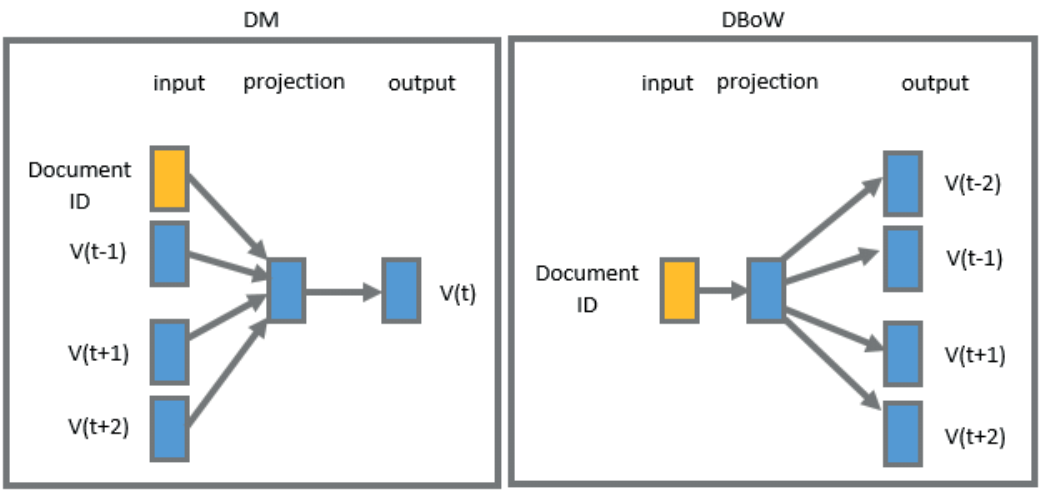

- DM : Distributed Memory
  - 벡터와 앞의 단어들을 사용해서 다음에 나오는 단어를 유추
  - 윈도우 크기 내의 단어를 input으로 사용
  - 맨 앞에서부터 한 단어씩 훈련 데이터로 사용
  - 벡터가 학습시 문서의 주제를 잡아주는 메모리와 같은 역할을 수행
  - 일반적으로 DBow보다 더 성능이 우수
- DBoW : Distributed Bag of Word
  - ID를 가지고 단어를 랜덤하게 예측하는 방식

### 3.1 doc2vec 준비
- Doc2Vec 모델로 문서 벡터를 만들기 위해서는, 각 문서를 구분할 수 있는 태그(문서 ID)와 해당 문서를 구성하는 단어(토큰) 목록이 함께 필요함
- gensim TaggedDocument 클래스 활용

In [22]:
import gensim
# 자연어 처리, 토픽 모델링을 위한 라이브러리
from gensim.models.doc2vec import TaggedDocument # 문서 태깅 클래스

In [23]:
df['tagged_review'][1][:5]

['근로', '일수', '체우', '지각', '조퇴']

In [24]:
# TaggedDocument 예시
TaggedDocument(
    tags = ['document'], # 각 문서를 구분할 수 있는 태그(문서 ID)
    words = df['tagged_review'][1] # 해당 문서를 구성하는 단어(토큰) 목록
)
# tags의 경우, 리스트로 패킹해서 여러 문서 태그를 부여할 수도 있지만,
# 보통은 문서별로 하나의 태그(예 : 'document 1')만 사용하는 편이 많음

TaggedDocument(words=['근로', '일수', '체우', '지각', '조퇴', '상관없다', '건가', '근로계약서', '지키다', '지키다', '말', '노동부', '신고', '그렇다', '업', '보상', '받다', '토일', '주휴수당', '출근', '하루', '아프다', '오전', '병원', '가다', '오후', '출근', '거', '주휴수당', '받다', '코웍님', '안녕하다', '주휴수당', '정리', '영상', '감사하다', '여쭈다', '볼', '근로계약서', '작성', '받다', '수', '인지', '궁금하다', '시급', '주휴수당', '받다', '조건', '라면', '받다', '그렇다', '명절', '빨갛다', '날', '쉬다', '쉬다', '경우', '주휴수당', '받다', '수', '회사', '근로계약서', '주', '주휴수당', '지급', '조항', '근로기준법', '문제', '없다', '궁금하다', '참고', '저녁', '새벽', '주휴수당', '계산', '시급', '주휴수당', '알다', '주휴수당', '달라', '해도', '올해', '적용', '회사', '다니다', '한번', '받다', '적', '없다', '주변', '없다', '현실', '그렇다', '사장', '지금', '입장', '그렇다', '직원', '뽑다', '싶다', '않다'], tags=['document'])

In [25]:
tagged_corpus_list = [] # 문서 태깅 결과를 담아둘 리스트

# 각 문서에 접근하여 문서ID 태깅
for i, tokens in enumerate(df['tagged_review']):
  tagged_doc = TaggedDocument(tags = [f'document {i}'], words = tokens)
  tagged_corpus_list.append(tagged_doc)

In [26]:
len(tagged_corpus_list)

1068

In [27]:
from gensim.models import doc2vec

In [28]:
# 1. doc2vec 모델 초기화
model = doc2vec.Doc2Vec(
    vector_size = 100, # 학습할 벡터(임베딩)의 차원 수(100차원)
    alpha = 0.025, # 초기 학습률(learning rate)
    min_alpha = 0.001, # 학습 진행 중에 점차 감소시킬 최소 학습률
    # 최적의 값에 수렴하기 위해 학습을 진행하면서 학습률을 감소시킨다.
    window = 8 # 주변 단어(window) 범위 설정(앞뒤 8개 단어)
)

In [29]:
# 2. 단어 사전(vocabulary) 생성
# TaggedDocument 리스트를 토대로 전체에 등장하는 단어들을 모델에 등록
model.build_vocab(tagged_corpus_list)

In [30]:
# 모델이 인식하고 있는 문서의 총 개수
model.corpus_count

1068

In [31]:
# 3. doc2vec 모델 학습 - 문서 벡터와 단어 벡터를 기반으로 학습
model.train(
    tagged_corpus_list,
    total_examples = model.corpus_count, # 전체 문서 개수
    epochs = 5 # 학습 반복 횟수(너무 크면 과적합의 가능성 / 학습속도 느려짐)
)

In [32]:
model.dv['document 0'].shape

(100,)

In [33]:
vector_list = [] # 문서 벡터들을 담아둘 리스트

for i in range(len(df)):
  doc2vec_vector = model.dv[f'document {i}'] # 각 문서 벡터에 접근
  vector_list.append(doc2vec_vector)

In [34]:
df['vector'] = vector_list

In [35]:
df.head()

,review,review_clean,tagged_review,vector
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.03233007, -0.042465344, -0.02150434, 0.043..."
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.01653695, -0.009189915, -0.0042386884, 0.0..."
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.0814732, -0.06178973, 0.006639014, 0.05544..."
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.037000623, -0.027148403, 0.00010979785, 0...."
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.101767205, -0.00992655, 0.043886546, 0.005..."


In [36]:
df.to_pickle('data/df_vector.pkl')

In [37]:
import pandas as pd

df = pd.read_pickle('data/df_vector.pkl')

In [38]:
df.head()

,review,review_clean,tagged_review,vector
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.03233007, -0.042465344, -0.02150434, 0.043..."
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.01653695, -0.009189915, -0.0042386884, 0.0..."
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.0814732, -0.06178973, 0.006639014, 0.05544..."
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.037000623, -0.027148403, 0.00010979785, 0...."
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.101767205, -0.00992655, 0.043886546, 0.005..."


In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# dendrogram : 계층적 군집 결과(linked)를 트리 형태로 시각화
# linkage : 계층적 군집(Hierarchical Clustering)을 수행

In [40]:
# 계층적 군집 수행
linked = linkage(
    list(df['vector']), # 군집화 할 데이터(군집 알고리즘 내에서 요구하는 입력포맷에 맞게 형변환)
    'ward' # 군집 방식 지정(여기서는 'ward' -> 군집 내 분산을 최소화)
)
# linkage : 2차원 배열형태 데이터 요구 (지금 데이터 vector가 리스트에 담겨있기 때문에 그대로 사용해도됨)

In [41]:
# df['vector']에 1068개 문서가 있다면, 계층적 군집에서 문서가 전부 하나로 합쳐질 때까지 총 1067번의 병합(=n-1)이 일어남
linked.shape

# (1067,4)
# -> 1067번의 병합 단계, 4ea의 컬럼

(1067, 4)

In [42]:
linked[0]
# -> 4ea의 컬럼[클러스터1 인덱스, 클러스터2 인덱스, 군집 간 거리, 병합된 후 새 클러스터가 포함하는 데이터 포인트 수]

array([2.71000000e+02, 5.93000000e+02, 7.31706363e-02, 2.00000000e+00])

In [43]:
df['vector'].shape

(1068,)

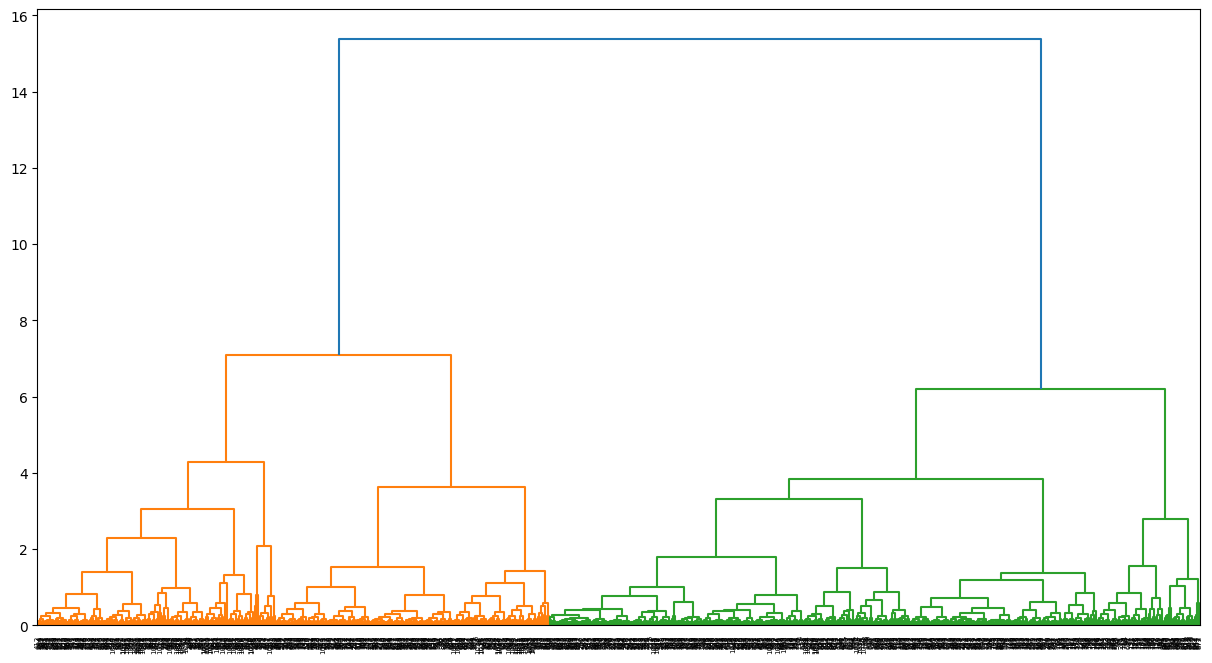

In [44]:
# 덴드로그램 시각화
plt.figure(figsize=(15,8))

dendrogram(
    linked, # 계층적 군집 결과
    orientation = 'top', # 덴드로그램의 방향(위에서 아래로 그리기(left,right,bottom))
    distance_sort = 'descending', # 클러스터 간 거리를 기준으로 내림차순 정렬
    show_leaf_counts = True, # 리프 노드(최종 말단)마다 샘플 개수 표시 여부
    color_threshold = 8 # y축 기준 -> 8 이상은 동일 색상(군집)으로 묶이지 않도록 설정
)

plt.show()

# y축 값이 낮은 지점에서 클러스터링 된 문서들은 서로 비슷한 내용일 가능성이 높음
# y축 값이 높은 곳에서 합쳐지는 문서들은 거리가 멀었다가 뒤늦게 합쳐진 것이므로, 서로 상이한 주제를 가질 수 있음

# 덴드로그램에서 threshold를 기준으로 크게 2개의 군집으로 나뉨
# 약 8 지점에서 자르면 2개 큰 군집으로 나누어지고, 더 아래로 자르면 3~4개 이상의 세부 군집으로 나눠볼 수는 있음(분석가의 몫)

In [45]:
# 1. 클러스터 초기화
cluster = AgglomerativeClustering(n_clusters=5)

NameError: name 'AgglomerativeClustering' is not defined

In [ ]:
# 2. 클러스터링 (군집화)

In [ ]:
# 3. 평균 실루엣 지수 계산

In [ ]:
# 각 클러스터별 평균 실루엣 지수 확인

